<a href="https://colab.research.google.com/github/valentinaslisser/mlandmlops/blob/main/Assignment_3c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3c Cognitive Modelling, deadline = vrijdag 22 mei 23:59

<a target="_blank" href="https://colab.research.google.com/github/uva-cogmod/a3c/blob/main/Assignment_3c.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Dit is onderdeel van de derde opdracht voor Cognitive Modelling, assignment 3 bestaat in totaal uit 3 onderdelen:

* Assignment 3a (47 punten)
* Assignment 3b (19 punten)
* __Assignment 3c (23 punten)__, vereist Colab / GPU

Geef antwoorden in blokken met code of met tekst. Gebruik voor antwoorden met tekst de ">" voor blockquotes en geef bij elke vraag ook __kort uitleg__ als hier om wordt gevraagd. __Let op__: soms staan er meerdere vragen bij een onderdeel, lees de tekst dus nauwkeurig.

Sla het uiteindelijke notebook op met jullie studentnummers en achternamen in de filenaam: `studentnummer1_achternaam1_studentnummer2_achternaam2_opdrachtnummer`.

---

### Voorbereiding: de Colab environment

Koppel je notebook aan een GPU: ga naar **Edit > Notebook settings** of **Runtime > Change runtime type** en selecteer (T4) GPU as Hardware accelerator.

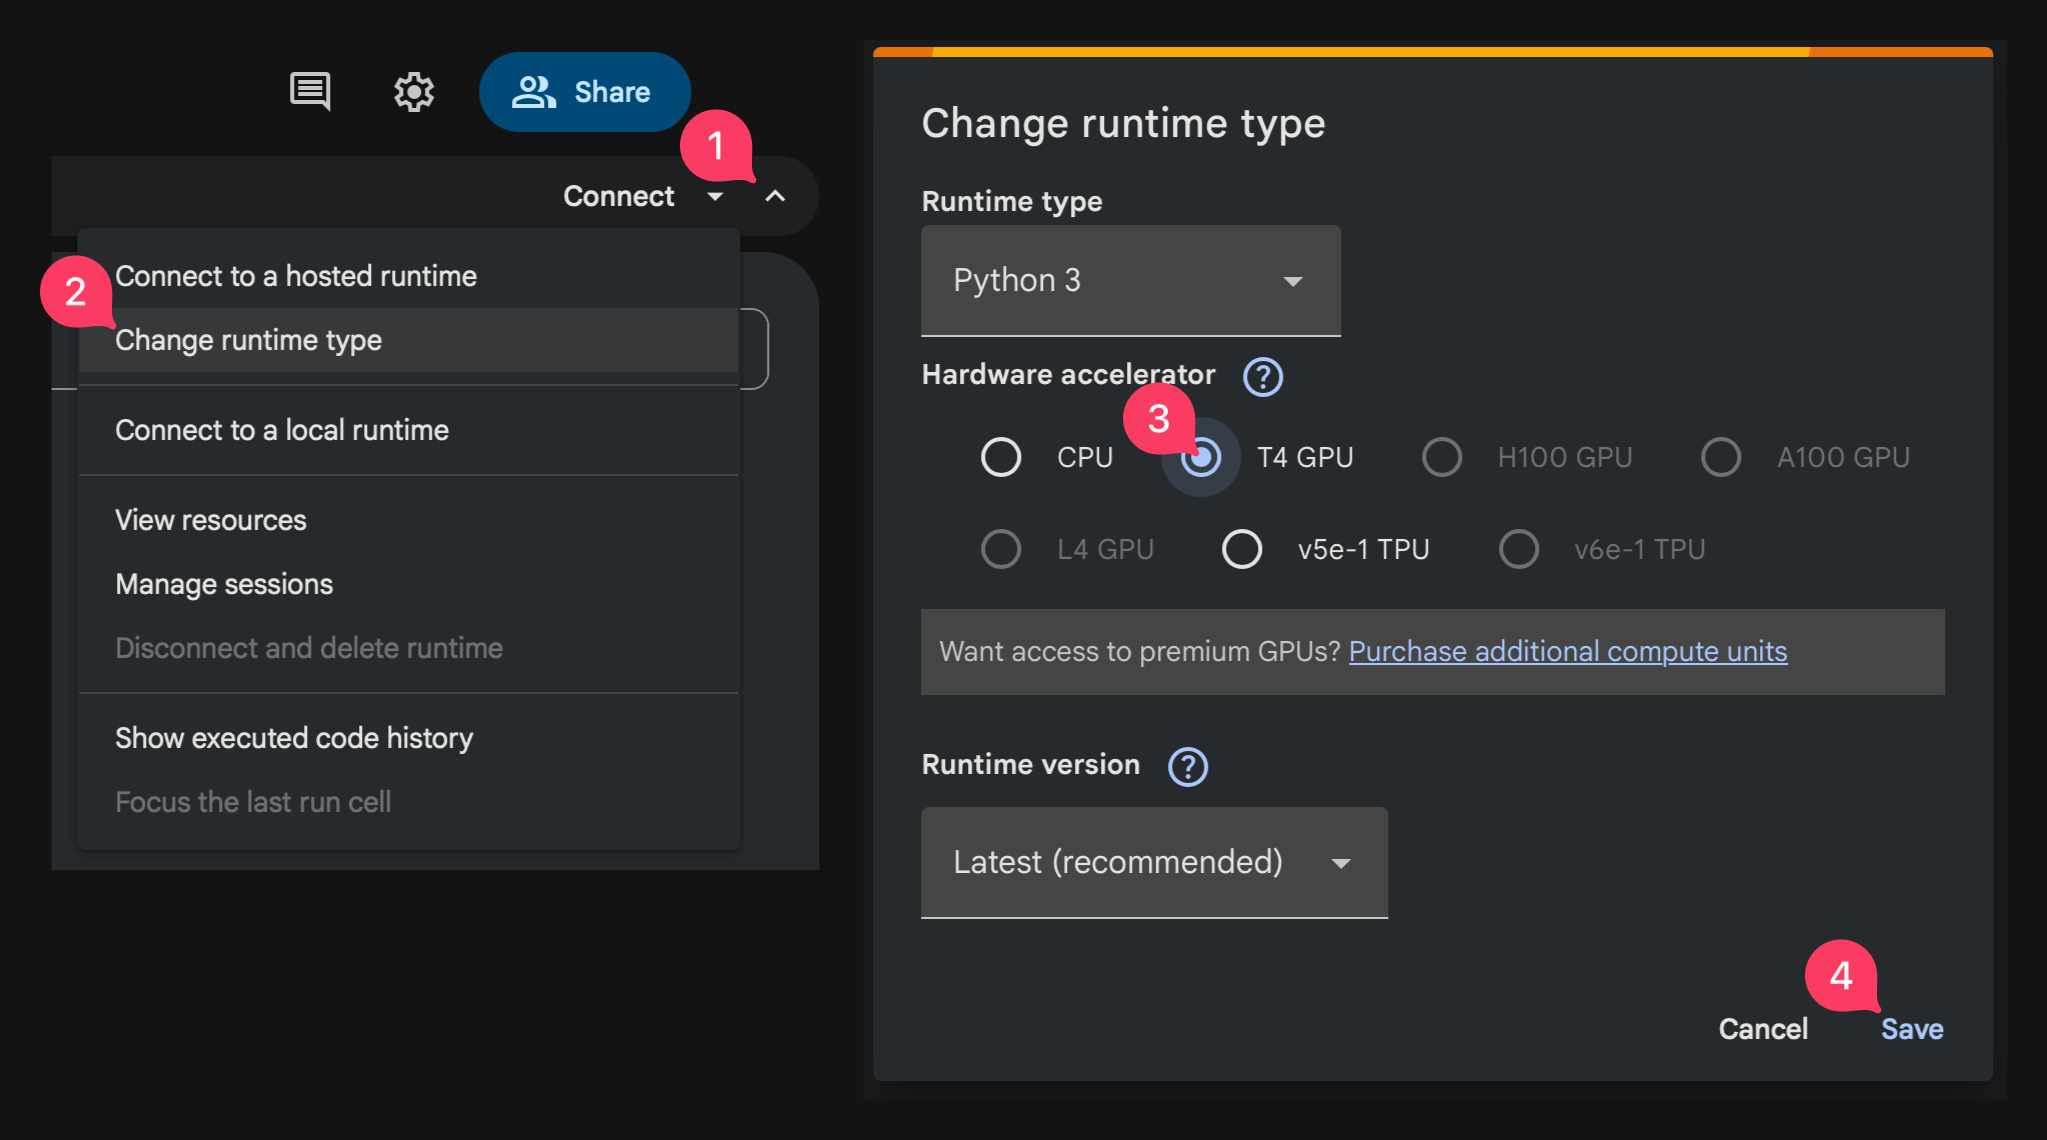


Nu moet je jouw Google Drive koppelen aan deze omgeving zodat je resultaten opgeslagen worden in je Drive. Hiervoor zal een pop-up komen die vraagt of de notebook toestemming heeft om in je Drive te schrijven; geef __alle__ toestemmingen die gevraagd worden, anders werkt het niet.

In [ ]:
import os
from pathlib import Path
from urllib.request import urlretrieve

In [ ]:
from google.colab import drive

drive.mount("/content/drive/")

assert Path("/content/drive/MyDrive").exists(), "Google Drive not mounted?"

We verplaatsen ons nu naar de juiste plaats in je Google Drive, in een mapje genoemd "CogMod Doom".

In [ ]:
base_dir = Path("/content/drive/MyDrive/Colab Notebooks/CogMod Doom")
base_dir.mkdir(parents=True, exist_ok=True)
os.chdir(base_dir)

Daarna downloaden we twee configuratie-files die nodig zijn voor het spel.

In [ ]:
github = "https://github.com/uva-cogmod/a3c/raw/refs/heads/main"
urlretrieve(f"{github}/basic.cfg", "basic.cfg")
urlretrieve(f"{github}/basic.wad", "basic.wad")
print("Files downloaded!")

Als laatste moeten we nog VizDoom installeren (de library waarmee we via Python, Doom kunnen spelen), torchinfo installeren (een utility om modellen te bekijken) en libraries importeren.

In [ ]:
!pip install vizdoom torchinfo --quiet

In [ ]:
import torch
import torch.utils.tensorboard
import collections
import numpy as np
import torch.nn as nn
import torch.optim as optim
import vizdoom
import skimage
import imageio
import torchinfo
import tqdm.auto as tqdm

Ondertussen kan je kijken naar dit plaatje van het spel die we het model gaan laten spelen:

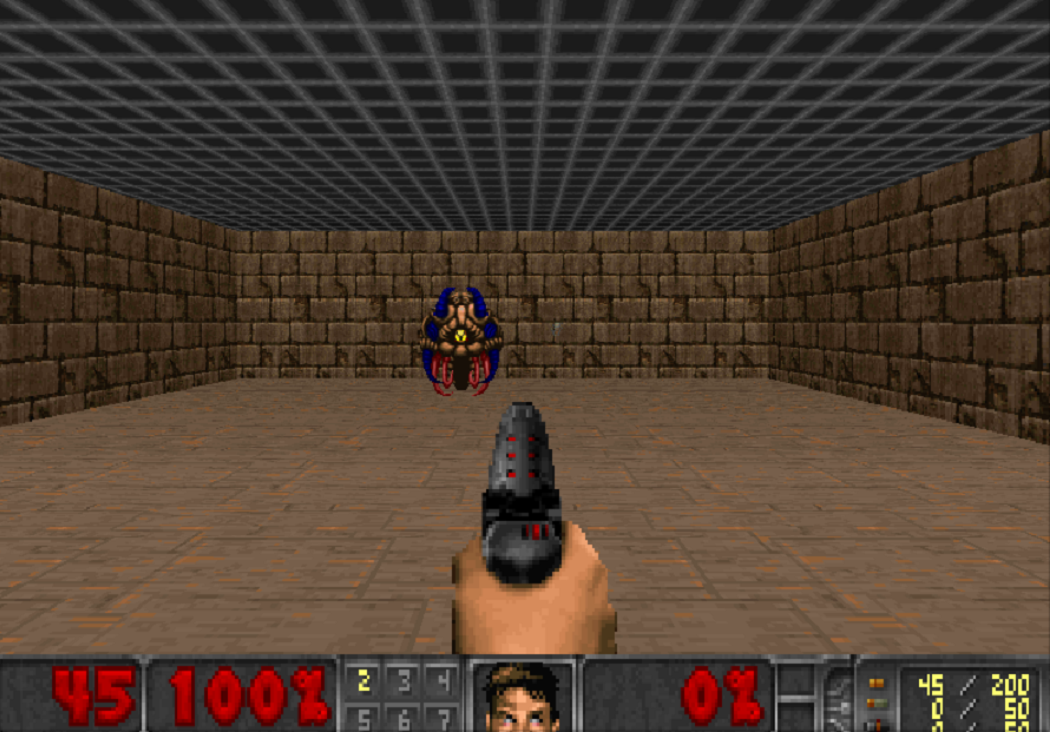


---

## De regels van het spel ﷿﷿﷿﷿
Nu we alle libraries hebben, kunnen we de regels van het spel bepalen. Doom wordt bepaald door:
  - Een  `configuration file` "basic.cfg" daar in vinden alle opties (frame size, mogelijke handelingen)
  - Een `scenario file`: "basic.wad" deze genereert het correcte scenario (ruimte, monsters etc., komt bij vizdoom).

Open beide files met een text-editor en bestudeer ze kort, kijk of je de belangrijkste elementen kan ontcijferen (en later mogelijk veranderen). Het spel ziet er als volgt uit:

__De omgeving:__
- Een monster staat op een willekeurige plek aan de overkant van het veld
- De speler heeft drie mogelijke acties: naar links, naar rechts en schieten
- 1 hit is genoeg om het monster uit te schakelen
- Een episode is over als het monster is geraakt of door een timeout (300).

__De rewards:__
- <font color='#FF0000'> -5 </font> punten voor het schieten van een kogel
- <font color='#FF0000'> -1 </font>punt voor elke tijdstap (energy consumption)
- <font color='#00FF00'> +100 </font> punten voor het uitschakelen van het monster

In [ ]:
game: vizdoom.DoomGame | None = None


def reset_game():
    global game

    game = vizdoom.DoomGame()
    # Load downloaded configuration and scenario
    game.load_config("basic.cfg")
    game.set_doom_scenario_path("basic.wad")

    # Unfortunately, we can't watch the game on colab (only locally)
    game.set_window_visible(False)
    game.init()


reset_game()

# We have three possible actions, represented
# using one-hot encoding
possible_actions = (
    (True, False, False),  # Move left
    (False, True, False),  # Move right
    (False, False, True),  # Shoot
)

---

### Preprocessing ﷿﷿﷿﷿﷿﷿

Preprocessing is een belangrijke stap, omdat we de complexiteit van onze data willen verminderen om zo de rekentijd die nodig is voor training te verminderen. In termen van leren kan je deze stap zien als een leraar die de leerling alleen vertelt in welke richting te kijken. Minimale supervision, maar dit helpt de leerling wel door de aandacht te vestigen in de juiste richting.

__Preprocessing stappen:__
- Grijstinten maken van alle frames (omdat kleur geen belangrijke informatie toevoegt). Dit wordt al gedaan door het configuratiebestand (!).
- Het scherm bijsnijden (in ons geval verwijderen we het dak omdat het geen informatie bevat)
- Het normaliseren van de pixelwaarden
- Het verkleinen van het preprocessed frame.

Dit resulteert in een 84x84 grayscale frames.

In [ ]:
def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    # The gray-scaling is already done in our vizdoom config,
    # but we could've done it manually with `skimage.color.rgb2gray`

    # Crop the screen (remove the roof, because it contains no information)
    cropped_frame = frame[30:-10, 30:-30]

    # Normalise pixel values from [0, 255] to [0, 1]
    normalised_frame = cropped_frame.astype(np.float32) / 255.0

    # Resize
    return skimage.transform.resize(normalised_frame, (84, 84))

<br>

---

### Stacked Frames ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

Als input states gaan we dus nu geen single frames gebruiken, maar een stapeltje (stacked) frames. Het stapelen van frames is erg belangrijk omdat het een gevoel van beweging/tijd meegeeft aan het neurale netwerk. Eerst preprocessen we het frame, vervolgens voegen we het frame toe aan een *deque* dat automatisch het oudste frame verwijdert, dan bouwen we de state (S) van deze frames.

Dit is hoe de class werkt:
- Voor de start state voeren we 4 keer hetzelfde begin frame in
- Bij elke tijdsstap voegen we het nieuwe frame toe aan de deque, en wordt het oudste frame weggehaald. Deze nieuwe stack is dan de nieuwe state
- Enzovoort
- Als een episode voorbij is, maken we een nieuwe stapel met 4 nieuwe frames (omdat we ons in een nieuwe episode bevinden).

Hier is nog een meer in depth artikel over stacked frames:  <a href="https://danieltakeshi.github.io/2016/11/25/frame-skipping-and-preprocessing-for-deep-q-networks-on-atari-2600-games/">  Frame skipping and preprocessing</a>.

In [ ]:
FRAME_STACK_SIZE = 4


class FrameStack:
    def __init__(self, stack_size: int = FRAME_STACK_SIZE) -> None:
        self.deque = collections.deque(maxlen=stack_size)

    def new_episode(self, first_frame: np.ndarray) -> torch.Tensor:
        # For a new episode, we fill the deque with `stack_size` copies of `first_frame`
        self.deque.clear()
        frame = preprocess_frame(first_frame)
        self.deque.extend(frame for _ in range(self.deque.maxlen))

        # We then return the state. Note that we stack along axis 0, to obtain a (C, H, W) tensor
        return torch.as_tensor(np.stack(self.deque, axis=0))

    def add_frame(self, new_frame: np.ndarray) -> torch.Tensor:
        # When we receive a new frame, we place it at the end of the queue, then return the state
        frame = preprocess_frame(new_frame)
        self.deque.append(frame)
        return torch.as_tensor(np.stack(self.deque, axis=0))

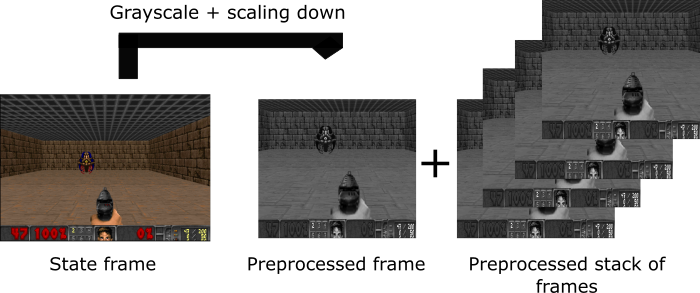


### ﷿﷿﷿ __Q1 (1 punt)__
Dubbel-check of je het volgt: de input van het model is een tensor van $4\times84\times84$. Waarom de $4$, en waarom de $84$?


> *Antwoord* <font color="red">TODO</font>

---

## Deep Q-learning Neural Network model bouwen ﷿﷿﷿﷿

Dit is de structuur van het Deep Q-learning model (zie ook de afbeelding hieronder):
- We nemen de stacked frames as input
- Deze input gaat door 3 convnets
- De data wordt platgeslagen (flattened), en gaat dan door twee fully connected layers.

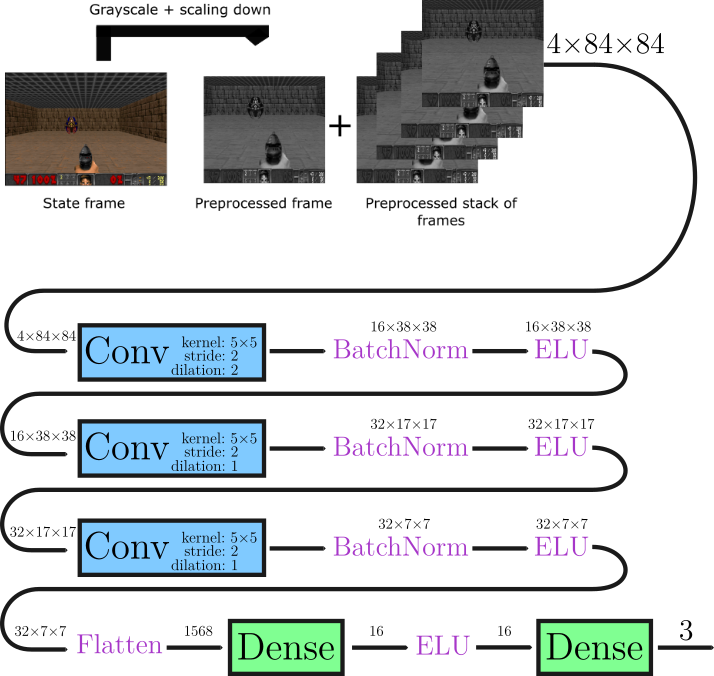


Bestudeer de code onder vraag 3 bij `class DQNetwork`, kijk in hoeverre je de structuur zoals hier boven beschreven terug kan lezen. Het is nu niet belangrijk dat alle details helemaal begrijpt, maar wel de grote lijnen.

### ﷿﷿﷿__Q2. Network Questions (4 punten)__

1. Hoeveel nodes heeft de laatste laag, en wat representeert deze laag?
2. Welke activatie functie gebruikt het netwerk?
3. Welke decision rule wordt er toegepast?

> *Antwoord* <font color="red">TODO</font>

In [ ]:
class DQNetwork(nn.Module):
    def __init__(
        self,
        state_channels: int = FRAME_STACK_SIZE,
        action_size: int = len(possible_actions),
    ) -> None:
        super().__init__()
        self.net = nn.Sequential(
            # Convolutional layers
            nn.Conv2d(
                in_channels=state_channels,
                out_channels=16,
                kernel_size=5,
                stride=2,
                dilation=2,
            ),
            nn.BatchNorm2d(num_features=16),
            nn.ELU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=2),
            nn.BatchNorm2d(num_features=32),
            nn.ELU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=2),
            nn.BatchNorm2d(num_features=32),
            nn.ELU(),
            # Fully connected layers
            nn.Flatten(),
            nn.LazyLinear(out_features=16),  # determines input size on the first run
            nn.ELU(),
            nn.Linear(in_features=16, out_features=action_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    @torch.no_grad()
    def decide(
        self, rng: np.random.Generator, state: torch.Tensor, explore_prob: float
    ) -> int:
        # We return the index of the action we want to take in this state
        if rng.random() < explore_prob:
            return int(rng.choice(len(possible_actions)))

        self.eval()
        qs = self(state.unsqueeze(0))
        self.train()

        return int(qs.argmax())

In [ ]:
torchinfo.summary(DQNetwork(), input_size=(1, 4, 84, 84))

Als het goed is heb je bij Computer Vision alles over Convnets geleerd en ook bij andere vakken over Neural Networks. Maar om toch even kort terug naar de theorie. Waarom gebruiken we hier niet een simpel one-layer network, of waarom geen Q-tables zoals we hiervoor hebben gedaan? De reden is de grootte van de state-space.


### ﷿﷿﷿__Q3. (2 punten)__
- Als we aannemen dat iedere pixel of aan (1) of uit (0) staat, hoe groot is de state-space (na pre-processing)?
- Hoeveel state-action pairs zijn er dan?
- Als we aannemen dat iedere pixel ongeveer $2^{20}$ waardes tussen 0 en 1 aan kan nemen, hoeveel state-action pairs zijn er dan?

> *Antwoord* <font color="red">TODO</font>

<br>

Precies! Dat is al heel erg groot en dit spel is nog steeds erg beperkt. Stel je voor dat je nog door de ruimte kan bewegen etc. We zagen al dat het grotere Frozen Lake van 8x8 lastig was voor Q-tables. Dit is niet te doen. Convnets kunnen de agent de state-space laten doorgronden en laten generaliseren.

Een convnet kan gebruik maken van spati﷿﷿le relaties: denk bijvoorbeeld aan dat als het monster twee stappen links van jou staat, je altijd LEFT, LEFT, SHOOT zou moeten doen, ongeacht of het monster helemaal links staat of in het midden. Als je deze relaties kan gebruiken om te leren is dat dus heel handig. Een Q-table aanpak zou voor state monster_links en state monster_midden geheel opnieuw moeten leren wat de beste actie is.

Meer lezen over convolutional nets:
https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53

---

### De hyperparameters voor de training ﷿﷿﷿﷿
In dit deel defini﷿﷿ren wij de hyperparameters voor het trainen van het model:

In [ ]:
# Hyperparameters
NUM_EPISODES = 501  # Total episodes for training
BATCH_SIZE = 64  # Batch size for experience replay
LEARNING_RATE = 0.0025  # Alpha (aka learning rate)
MAX_STEPS = 100  # Max possible steps in an episode
SAVE_EVERY = 50  # Save every 50 episodes

EPSILON_START = 1.0  # Initial exploration probability
EPSILON_END = 0.01  # Minimum exploration probability
EPSILON_DECAY = 0.00008  # Exponential decay rate for exploration prob
EPSILON_DECAY = 0.00003  # Exponential decay rate for exploration prob
GAMMA_DISCOUNT = 0.95  # Discounting rate for future rewards

MEMORY_SIZE = 10_000  # Number of experiences the Memory can keep
INITIAL_MEMORY_FILL = BATCH_SIZE * 1  # ... the Memory starts with

Hier kijken wij welke _device_ we gaan gebruiken voor het uitvoeren van het model. Voor het trainen van het model is het __sterk aangeraden__ om een CUDA-omgeving te gebruiken.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

<br>

---

### Experience Replay ﷿﷿﷿﷿
Nu we ons neurale netwerk hebben gemaakt, gaan we de Experience Replay-methode implementeren. We defini﷿﷿ren een Experience object, die alle informatie voor een ervaring bij elkaar houdt. Daarna maken we een deque Memory-object, die de experiences bijhoudt. Net als bij de FrameStack is een deque (dubbele wachtrij) is een gegevenstype dat het oudste element verwijdert telkens wanneer er een nieuw element wordt toegevoegd.

We maken ook een functie `Memory.fill` die een Memory instantie opvult met random acties.

In [ ]:
from typing import NamedTuple


# This is just a tuple, but it has names and types for its elements
class Experience(NamedTuple):
    state: torch.Tensor  # stack of frames
    action_idx: int  # the index of the chosen action (0, 1 or 2)
    reward: float
    next_state: torch.Tensor
    done: bool  # episode over?

In [ ]:
class Memory:
    def __init__(self, max_experiences: int = MEMORY_SIZE) -> None:
        self.buffer = collections.deque(maxlen=max_experiences)

    def add(self, experience: Experience) -> None:
        self.buffer.append(experience)

    def sample(self, rng: np.random.Generator, batch_size: int) -> list[Experience]:
        # We grab `batch_size` random Experiences from the buffer
        index = rng.choice(len(self.buffer), size=batch_size, replace=False)
        return [self.buffer[i] for i in index]

    def __len__(self) -> int:
        return len(self.buffer)

    def fill(self, rng: np.random.Generator, up_to: int = MEMORY_SIZE) -> None:
        # Repeatedly take random actions and store the experiences
        game.new_episode()
        stack = FrameStack()
        state = stack.new_episode(game.get_state().screen_buffer)
        zero_state = torch.zeros_like(state)

        for _ in range(up_to - len(self.buffer)):
            action_idx = rng.choice(len(possible_actions))
            reward = game.make_action(possible_actions[action_idx])
            done = game.is_episode_finished()

            if done:
                self.add(Experience(state, action_idx, reward, zero_state, done))
                game.new_episode()
                state = stack.new_episode(game.get_state().screen_buffer)
            else:
                next_state = stack.add_frame(game.get_state().screen_buffer)
                self.add(Experience(state, action_idx, reward, next_state, done))
                state = next_state

---
### Optimisation and the training target ﷿﷿﷿﷿
Vervolgens defini﷿﷿ren wij een functie `calc_loss` om de loss te berekenen gegeven een batch van experiences, en `step_model` om een optimalisatie stap te nemen met een gegeven model.

In [ ]:
def calc_loss(
    model: DQNetwork,
    states: torch.Tensor,
    actions: torch.Tensor,
    rewards: torch.Tensor,
    next_states: torch.Tensor,
    dones: torch.Tensor,
    gamma: float,
):
    # We take the q-values from the current state for all actions taken
    qs = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # We take the maximum q-values for each next state
    next_qs = model(next_states).detach().amax(dim=1)

    # What do you recognize this as?
    target_qs = rewards + dones.logical_not() * gamma * next_qs
    return nn.functional.mse_loss(qs, target_qs)

In [ ]:
def step_model(
    model: DQNetwork,
    optimiser: torch.optim.Optimizer,
    memory: Memory,
    rng: np.random.Generator,
    gamma: float,
    batch_size: int = BATCH_SIZE,
) -> float:
    # Sample some experiences
    experiences = memory.sample(rng, batch_size)

    # Turn the list of experiences into separate arrays per type
    states, actions, rewards, next_states, dones = zip(*experiences, strict=False)
    states = torch.as_tensor(np.stack(states, dtype=np.float32), device=device)
    actions = torch.as_tensor(np.stack(actions, dtype=np.int64), device=device)
    rewards = torch.as_tensor(np.stack(rewards, dtype=np.float32), device=device)
    next_states = torch.as_tensor(
        np.stack(next_states, dtype=np.float32), device=device
    )
    dones = torch.as_tensor(np.stack(dones, dtype=np.bool), device=device)

    loss = calc_loss(model, states, actions, rewards, next_states, dones, gamma)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    return loss.detach().item()

---

## Training ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

Ons algoritme:

* Initialiseer de game omgeving
* Initialiseer de weights van het netwerk
* Initialiseer de decay rate voor e-greedy
* **For** episode to max_episode **do**
    * Make new episode
    * Observe the first state $s_0$
    * **For** step to max_step **do**
        * Increase decay_rate (decrease decay)
        * With $\epsilon$ select a random action $a_t$, otherwise select $a_t = \mathrm{argmax}_a Q(s_t,a)$
        * Execute action $a_t$ and observe reward $r_{t+1}$ and new state $s_{t+1}$
        * Store transition $<s_t, a_t, r_{t+1}, s_{t+1}>$ in memory $D$
        * Sample random mini-batch from $D$: $<s, a, r, s'>$
        * Set $\hat{Q} = r$ if the episode ends at $+1$, otherwise set $\hat{Q} = r + \gamma \max_{a'}{Q(s', a')}$
        * Make a gradient descent step with loss $(\hat{Q} - Q(s, a))^2$

Je ziet dat dit eigenlijk precies hetzelfde is als we eerder in het FrozenLake Q-net hadden geimplementeerd, alleen zitten er nu dus wel wat lagen tussen.

Iedere keer wordt onze epsilon volgens deze schedule ietsjes kleiner

In [ ]:
def exploration_schedule(decay_step: int):
    return EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(
        -EPSILON_DECAY * decay_step
    )

Dit is de hoofd-functie die het trainen regelt. Neem het even door, en kijk of je de verschillende onderdelen kan begrijpen.

In [ ]:
def fit_model(
    run_id: str,
    seed: int = 0,
    tb_log_dir: str = "./tensorboard/",
    episodes: int = None,  # defaults to NUM_EPISODES
    overwrite_ok: bool = False,
) -> None:
    log_file = Path(f"logs/{run_id}.csv")
    model_dir = Path(f"models/{run_id}")

    if log_file.exists() and not overwrite_ok:
        raise FileExistsError(
            f"This {run_id=} already has an associated log file, but we don't"
            f" support resuming from a previous training run."
            f" Either delete the old run, change the run_id or set overwrite_ok."
        )

    # create directories for the model and logs, and add CSV header
    log_file.parent.mkdir(exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)
    log_file.write_text("episode,reward,loss,memory_size,explore\n")
    writer = torch.utils.tensorboard.SummaryWriter(tb_log_dir, flush_secs=15)

    if episodes is None:
        episodes = NUM_EPISODES

    # create our source of randomness for this run
    seeds = np.random.SeedSequence(seed).generate_state(2 + episodes)
    rng = np.random.default_rng(seeds[0])
    torch.manual_seed(seeds[1])

    # initialise network, optimiser, memory
    model = DQNetwork().to(device)
    optimiser = optim.RMSprop(model.parameters(), lr=LEARNING_RATE)
    memory = Memory()

    # sanity check: all outputs are valid
    reset_game()
    stack = FrameStack()
    black_frame = np.zeros_like(game.get_state().screen_buffer)
    example_input = stack.new_episode(black_frame)
    example_output = model(example_input.unsqueeze(0).to(device))
    assert torch.isfinite(example_output).all(), "Model not working!"

    # fill up the memory with enough samples to
    # take batches for optimisation of the network
    memory.fill(rng, up_to=INITIAL_MEMORY_FILL)

    # the global step is used to adjust the epsilon value
    # it will lower our exploration rate as it increases
    global_step = 0

    # tqdm progress bar
    bar = tqdm.tqdm(
        enumerate(seeds[2:]), desc="Training", unit="ep", smoothing=0.01, total=episodes
    )
    for episode, seed in bar:
        game.set_seed(seed)
        game.new_episode()

        state = stack.new_episode(game.get_state().screen_buffer)
        episode_reward = 0
        episode_loss = 0
        for _ in range(MAX_STEPS):
            global_step += 1

            # select action based on the current state and epsilon
            epsilon = exploration_schedule(global_step)
            action_idx = model.decide(rng, state.to(device), epsilon)

            # execute action
            reward = game.make_action(possible_actions[action_idx])
            episode_reward += reward
            done = game.is_episode_finished()  # Check if the episode is finished

            # bookkeeping
            next_frame = game.get_state().screen_buffer if not done else black_frame
            next_state = stack.add_frame(next_frame)
            memory.add(Experience(state, action_idx, reward, next_state, done))
            state = next_state

            # replay previous experiences in memory
            # this is the part that actually adjusts / trains the model!
            episode_loss += step_model(model, optimiser, memory, rng, GAMMA_DISCOUNT)

            if done:
                break

        # update progress bar and logs, maybe save model
        epsilon = exploration_schedule(global_step)
        bar.set_postfix(reward=episode_reward, loss=episode_loss, explore=epsilon)
        writer.add_scalar(f"{run_id}/Loss", episode_loss, episode)
        writer.add_scalar(f"{run_id}/Reward", episode_reward, episode)
        writer.flush()

        with log_file.open("a") as csv:
            csv.write(
                f"{episode},{episode_reward},{episode_loss},{len(memory)},{epsilon}\n"
            )

        if episode % SAVE_EVERY == 0:
            torch.save(model.state_dict(), f"{model_dir}/{episode}.pth")

    # save the final version of the model, and close the tensorboard writer
    torch.save(model.state_dict(), f"{model_dir}/{episodes}.pth")
    writer.close()

Nu eventjes kijken of alles werkt!

FYI: We schakelen hier twee features (low precision matmuls en CuDNN benchmarking) uit om resultaten te krijgen die makkelijker te repliceren zijn door anderen.

In [ ]:
torch.backends.cudnn.benchmark = False
fit_model(run_id="sanity_check", episodes=2, overwrite_ok=True)
print("Ready!")

---

### Tensorboard ﷿﷿﷿﷿

Tensorboard is een dashboard die in een Jupyter Notebook kan runnen, waarmee je kan volgen hoe je model zit te trainen. In de vorige functie zag je dat we data wegzetten via de `writer`, maar we moeten het natuurlijk ook af kunnen lezen. We maken hier een functie aan die het dashboard op zal starten.

In [ ]:
import tempfile


def load_tensorboard(log_dir: str = "./tensorboard/"):
    log_dir = Path(log_dir).resolve()
    log_dir.mkdir(parents=True, exist_ok=True)

    # TensorBoard can be pretty flakey, so it's best to just kill all previous processes.
    !pkill -f tensorboard
    tb_cache = Path(tempfile.gettempdir(), ".tensorboard-info")
    if tb_cache.exists():
        for cache_item in tb_cache.iterdir():
            cache_item.unlink()

    %reload_ext tensorboard
    %tensorboard --logdir="$log_dir"

### ﷿﷿﷿ __Q4.a (3 punten)__

Je gaat hieronder de agent trainen in 500 episodes met de huidige set hyperparameters, dit kan wel _ongeveer 12 minuten duren_, dus tijd om even pauze te nemen en de benen te strekken. Bekijk en rapporteer na afloop het gedrag van de agent tijdens het leerproces. Doe dit op twee manieren:

1. Aan de hand van de score die de agent behaalt tijdens het leren;
2. Aan de hand van hoe de agent het spel speelt (visueel, komt straks).

__1. Score__

  * Tijdens het trainen schrijft het script de output weg in **logs/\<run_id\>.csv** die kan worden gebruikt voor visualisatie van de leercurve(s). Deze wordt dus in je Google Drive geschreven.
  * Maak twee plots op basis van deze data: de leercurve met de score van de agent tijdens het leren, de kans op een exploratie. Zet in de grafieken de gemiddelde punten en explore probabilities voor bins van 10 episodes om de leercurven te illustreren en rapporteer ook het totaal aantal punten. Beschrijf wat je ziet.

In [ ]:
# Hier openen wij de Tensorboard dashboard
load_tensorboard()
# Voorlopig zie je alleen sanity_check, maar je kan
# op de tandwieltje drukken, en auto-refresh aanzetten.
# Dan zie je de loss en reward voor je echte run straks verschijnen.

In [ ]:
fit_model(run_id="base")

In [ ]:
# TODO: graphs

> *Antwoord* <font color="red">TODO</font>

### ﷿﷿﷿ __Q4.b (4 punten)__
__2. Visualisatie__

* De code hierboven slaat het model om de 50 episodes __\<episode\>.pth__ op in de directory __models/\<run_id\>__. Dit is de staat van het model na XX episodes trainen. De directory names specificeren dus weer het model.

  Met de code hieronder kan je de bovengenoemde outputfiles gebruiken om naar gedrag van de agent te kijken, gegeven de weights in het netwerk na een XX aantal leer episodes. Deze code laat slechts ﷿﷿﷿﷿n game zien (﷿﷿﷿﷿n episode), dus doe dit misschien een aantal keren omdat het anders net zo kan uitvallen dat de game begint dat de agent recht voor de alien staat en meteen neerschiet. Dat is goed, maar vertelt weinig over het gedrag.

  Naast deze ene game, slaat deze code ook de sequentie van states als lijst van screenshots op in `trajectory`. Deze `trajectory` kan je in een animatie te maken door ze achter elkaar te plakken. Je kan deze bekijken, en ook opslaan als mp4.

* Beschrijf het verschil in gedrag in __drie verschillende fasen__ (na episode 50, 150 en 500). Wat voor soort fouten zie je? Sla de vier .mp4 bestanden van deze drie fases op en __lever de bestanden in__.

In [ ]:
def save_trajectory(run_id: str, episode: int, output_name: str, seed: int = 0) -> None:
    model = DQNetwork().to(device).eval()
    model.load_state_dict(torch.load(f"models/{run_id}/{episode}.pth"))

    trajectory = []
    game.set_seed(seed)
    game.new_episode()

    stack = FrameStack()
    stack.new_episode(game.get_state().screen_buffer)

    while not game.is_episode_finished():
        frame = game.get_state().screen_buffer
        trajectory.append(frame.copy())
        state = stack.add_frame(frame)

        qs = model(state.unsqueeze(0).to(device))

        action = possible_actions[qs.argmax()]
        game.make_action(action)

    output = Path(f"videos/{run_id}/{episode}/{output_name}")
    output.parent.mkdir(parents=True, exist_ok=True)
    imageio.v3.imwrite(output, trajectory)
    print("Saved game with score", game.get_total_reward(), "to", output)

In [ ]:
NUM_TRAJ = 1

for traj, traj_seed in enumerate(np.random.SeedSequence(42).generate_state(NUM_TRAJ)):
    save_trajectory(
        run_id="base",
        episode=50,
        output_name=f"run_{traj}.gif",
        seed=traj_seed,
    )

> *Antwoord* <font color="red">TODO</font>

### ﷿﷿﷿__Q4c (2 Punten)__
Bestudeer bovenstaande code, hoe verschilt de decision policy van de gedragssimulatie met die van de training agent?

> *Antwoord* <font color="red">TODO</font>

<br>

---

### ﷿﷿﷿Q5 (7 punten)
Probeer nu de prestaties van het model te verbeteren en voer bovenstaande stappen nog eens uit. Dit kan je ondertussen op heel veel manieren doen, je kan bijvoorbeeld veranderingen maken aan de hyperparameters, exploratie regel, replay etc. Kijk of je sneller convergentie of betere resultaten kan krijgen!

* Train een aangepaste model
* Leg uit waarom je verwachtte dat jouw aanpassing het beter zou maken
* Laat zien of het werkte op basis van trainingsgrafiek (stap 1 hierboven)
* Kijk goed naar het gedrag na 500 episodes leren of je daar iets van kan afleiden (stap 2 hierboven).

Het gaat nu om je idee, niet meteen of het netwerk ook beter leert, maar dat is natuurlijk wel een mooie uitkomst!

In [ ]:
# TODO: adjust hyperparameters and retrain

> *Antwoord* <font color="red">TODO</font>

In [ ]:
# TODO: graphs

In [ ]:
# TODO: videos

# Type het AI Statement hieronder!